In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [2]:
data_path = "../Data/creditcard.csv"
df = pd.read_csv(data_path)

X = df.drop("Class", axis=1)
y = df["Class"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

In [5]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [6]:
model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)

In [7]:
print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall   :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_smote))

Accuracy : 0.9742108774270566
Precision: 0.058027079303675046
Recall   : 0.9183673469387755
F1 Score : 0.1091570648878108

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



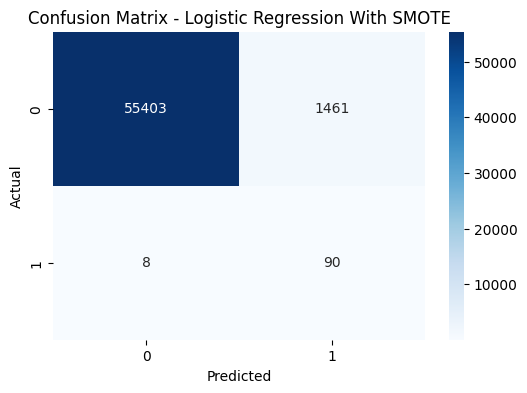

In [8]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_smote),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression With SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 🔥 SMOTE Analysis: Logistic Regression With vs Without SMOTE

---

# 🧠 How SMOTE Works

SMOTE stands for:

# Synthetic Minority Oversampling Technique

SMOTE is used when a dataset is highly imbalanced. In this project, the minority class is:

```text
Fraud Transaction = Class 1
```

and the majority class is:

```text
Non-Fraud Transaction = Class 0
```

Before applying SMOTE, the training data distribution was:

| Class         |  Count |
| ------------- | -----: |
| Non-Fraud (0) | 227451 |
| Fraud (1)     |    394 |

This means the model originally had very few fraud examples to learn from.

SMOTE solves this problem by creating new synthetic fraud samples instead of simply copying existing fraud rows.

---

# ⚙️ Mathematical Logic Behind SMOTE

SMOTE selects an existing minority class sample and finds its nearest minority class neighbors.

Then it creates a new synthetic point between the selected sample and one of its neighbors.

The general formula is:

```text
x_new = x_i + λ × (x_neighbor − x_i)
```

Where:

| Symbol     | Meaning                                        |
| ---------- | ---------------------------------------------- |
| x_i        | Existing fraud transaction                     |
| x_neighbor | Nearest fraud transaction selected as neighbor |
| λ          | Random value between 0 and 1                   |
| x_new      | Newly generated synthetic fraud transaction    |

This means the synthetic point is not a duplicate.
It is a newly created point located somewhere between two real fraud transactions in feature space.

---

# 🧩 Simple Example

Suppose one fraud transaction has a feature value:

```text
x_i = 10
```

and one of its nearest fraud neighbors has:

```text
x_neighbor = 16
```

If:

```text
λ = 0.5
```

then:

```text
x_new = 10 + 0.5 × (16 − 10)
x_new = 10 + 3
x_new = 13
```

So SMOTE creates a new synthetic fraud value between 10 and 16.

In the actual dataset, this process happens across all feature columns such as:

```text
Time, V1, V2, V3, ..., V28, Amount
```

So each synthetic fraud transaction is a complete artificial row created using the numerical relationships between real fraud transactions.

---

# 🧪 How Our SMOTE Code Works

The SMOTE code used in this notebook is:

```python
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
```

This code performs the complete oversampling process.

---

# 🔍 Step-by-Step Code Explanation

## 1. Creating the SMOTE Object

```python
smote = SMOTE(random_state=42)
```

This creates a SMOTE object.

The parameter:

```python
random_state=42
```

makes the synthetic sample generation reproducible.

That means every time the notebook is run, SMOTE will generate the same synthetic samples, making the experiment consistent and easier to compare.

---

## 2. Applying SMOTE on Training Data

```python
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
```

This is the most important line.

Here:

```text
X_train
```

contains the training features, and:

```text
y_train
```

contains the training labels.

SMOTE looks at the class distribution inside `y_train`.

Before SMOTE:

| Class         |  Count |
| ------------- | -----: |
| Non-Fraud (0) | 227451 |
| Fraud (1)     |    394 |

SMOTE identifies that fraud is the minority class.

Then, internally, it creates synthetic fraud samples until the minority class count becomes equal to the majority class count.

After SMOTE:

| Class         |  Count |
| ------------- | -----: |
| Non-Fraud (0) | 227451 |
| Fraud (1)     | 227451 |

So the line:

```python
fit_resample(X_train, y_train)
```

does two things:

| Step       | Meaning                                                         |
| ---------- | --------------------------------------------------------------- |
| `fit`      | Learns the minority class structure and nearest fraud neighbors |
| `resample` | Generates synthetic fraud rows and returns the balanced dataset |

---

# ⚙️ What Happens in the Backend

Internally, SMOTE performs the following steps:

1. It separates the minority class samples from the training data.
2. It finds nearest neighbors for each fraud sample using distance-based similarity.
3. It randomly selects one fraud sample and one of its nearest fraud neighbors.
4. It calculates the difference between the two fraud samples.
5. It multiplies that difference by a random number between 0 and 1.
6. It adds that value back to the original fraud sample.
7. This creates a new synthetic fraud transaction.
8. The process repeats until the fraud class count matches the non-fraud class count.

In simple terms:

```text
SMOTE studies the existing fraud transactions,
finds fraud transactions that are close to each other,
and creates new artificial fraud points between them.
```

---

# 🔗 How the Code Matches the Mathematical Formula

The formula is:

```text
x_new = x_i + λ × (x_neighbor − x_i)
```

The code:

```python
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
```

automatically applies this formula internally.

Here is how both connect:

| Mathematical Part  | Code-Level Meaning                                       |
| ------------------ | -------------------------------------------------------- |
| `x_i`              | One real fraud transaction from `X_train`                |
| `x_neighbor`       | One nearby fraud transaction found by SMOTE              |
| `λ`                | Random value generated internally by SMOTE               |
| `x_neighbor − x_i` | Direction between two similar fraud points               |
| `x_new`            | New synthetic fraud transaction added to `X_train_smote` |

So although the formula is not written manually in the code, the `fit_resample()` function performs this calculation internally for the minority class.

---

# 🚫 Why SMOTE Was Applied Only on Training Data

SMOTE was applied only after the train-test split.

This is very important.

Correct approach:

```text
Train-Test Split → Scaling → SMOTE on Training Data → Model Training → Testing
```

Incorrect approach:

```text
SMOTE on Full Dataset → Train-Test Split
```

The incorrect approach causes data leakage.

If SMOTE is applied before splitting, synthetic samples may be created using information from records that later go into the test set.

That would make the test performance unrealistic and overly optimistic.

In this notebook, SMOTE was correctly applied only to:

```text
X_train and y_train
```

The test set was kept untouched.

This ensures the model is evaluated on real unseen transactions.

---

# 📊 Model Performance Comparison

| Metric          | Without SMOTE | With SMOTE |            Change |
| --------------- | ------------: | ---------: | ----------------: |
| Accuracy        |        99.91% |     97.42% |         Decreased |
| Precision       |        82.89% |      5.80% | Decreased sharply |
| Recall          |        64.29% |     91.84% | Improved strongly |
| F1 Score        |        72.41% |     10.92% |         Decreased |
| False Negatives |            35 |          8 |          Improved |
| False Positives |            13 |       1461 |         Increased |

---

# 🧠 Interpretation of the Comparison

## Accuracy: 99.91% → 97.42%

Accuracy decreased after applying SMOTE.

This happened because the model became less biased toward predicting the majority class, which is non-fraud.

Before SMOTE, the model was conservative and mostly predicted transactions as non-fraud.

After SMOTE, the model became more sensitive toward fraud detection, so it predicted more transactions as fraud.

This reduced overall accuracy slightly, but improved the model’s ability to identify fraud.

---

## Precision: 82.89% → 5.80%

Precision dropped sharply after SMOTE.

This happened because the model started flagging many more transactions as fraud.

From the confusion matrix:

| Case            | Without SMOTE | With SMOTE |
| --------------- | ------------: | ---------: |
| False Positives |            13 |       1461 |

So after SMOTE, many genuine transactions were incorrectly classified as fraud.

This means the model became aggressive in detecting fraud, but at the cost of producing many false alarms.

---

## Recall: 64.29% → 91.84%

Recall improved significantly after SMOTE.

This is the strongest positive outcome.

From the confusion matrix:

| Case            | Without SMOTE | With SMOTE |
| --------------- | ------------: | ---------: |
| False Negatives |            35 |          8 |

Without SMOTE, the model missed 35 fraud transactions.

With SMOTE, it missed only 8 fraud transactions.

This means SMOTE helped the Logistic Regression model learn the fraud class better and detect more actual fraud cases.

---

## F1 Score: 72.41% → 10.92%

F1 Score decreased heavily after SMOTE.

Even though Recall improved, Precision dropped too much.

Since F1 Score balances Precision and Recall, the very low Precision pulled the F1 Score down.

This shows that SMOTE improved fraud detection sensitivity, but the overall balance between correct fraud alerts and false alarms became weaker.

---

# 🏦 Business Interpretation

After SMOTE, the model became much better at catching fraud.

However, it also started flagging many genuine transactions as fraud.

This creates a real business decision.

| Business Priority                  | Preferred Model Behavior |
| ---------------------------------- | ------------------------ |
| Catch maximum frauds               | Higher Recall            |
| Avoid disturbing genuine customers | Higher Precision         |
| Reduce missed frauds               | Lower False Negatives    |
| Reduce false alarms                | Lower False Positives    |

---

# ⚖️ Final Tradeoff

SMOTE reduced missed fraud cases:

```text
False Negatives reduced from 35 to 8
```

This is valuable because missed fraud can directly lead to financial loss.

However, SMOTE also increased false alarms:

```text
False Positives increased from 13 to 1461
```

This can increase manual review workload, operational cost, and customer inconvenience.

Therefore, the final conclusion is:

# SMOTE significantly improves Recall, but it can severely reduce Precision.

So SMOTE should not be treated as the final solution by itself.

It should be combined with:

* threshold tuning
* better models
* precision-recall curve analysis
* cost-sensitive evaluation
* alternative imbalance handling techniques

This experiment clearly demonstrates the core tradeoff in imbalanced fraud detection:

# Higher fraud detection sensitivity vs higher false alarm rate.
